# Mini-projet CNN

Dans cette séance, vous mobilisez ce qui a été vu aux
séances précédentes sur un problème un cran plus
réaliste.

**Consigne.** Dasn cette séance, seule la préparation des données est fournie, tout le retse est à réaliser par vous-mêmes. Le travail porte sur les choix de modélisation :

- architecture  ;
- régularisation ;
- optimiseur ;
- data augmentation (via `torchvision.transforms`, cf partie 0).

Vous devez comparer **au moins 3 configurations** et justifier vos choix à partir des courbes
d'apprentissage (train vs val), pas seulement du score final.

**Données.** Vous travaillerez sur un sous-ensemble de CIFAR-10 (images couleur 32x32, 10 classes), volontairement
réduit pour que les entraînements restent raisonnables sur CPU en séance.


In [ ]:
# !pip install -q torch torchvision matplotlib

import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import transforms

import matplotlib.pyplot as plt

from training_toolbox import Trainer, EarlyStopping, ModelCheckpoint, accuracy, count_trainable_parameters

torch.manual_seed(0)


## Partie 0 — Données

On sous-échantillonne CIFAR-10 (1 image sur 4 pour l'entraînement) pour garder des temps
d'entraînement compatibles avec une séance de TP sur CPU. Deux jeux de transforms sont
fournis : un sans augmentation, un avec (recadrage aléatoire + flip horizontal, classiques
sur des images naturelles).


In [2]:
CLASSES = [
    "avion", "voiture", "oiseau", "chat", "cerf",
    "chien", "grenouille", "cheval", "bateau", "camion",
]

MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)

transform_plain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Deux instances du même dataset, avec des transforms différents : pratique pour basculer
# facilement de l'un à l'autre sans redéfinir le sous-échantillonnage.
train_full_plain = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_plain
)
train_full_augmented = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_augmented
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_plain
)

# Sous-échantillonnage : 1 exemple sur 4, indices partagés entre train/val
indices = list(range(0, len(train_full_plain), 4))
n_val = len(indices) // 5
val_indices, train_indices = indices[:n_val], indices[n_val:]

val_set = Subset(train_full_plain, val_indices)          # jamais augmenté
train_set_plain = Subset(train_full_plain, train_indices)
train_set_augmented = Subset(train_full_augmented, train_indices)

print(f"Train : {len(train_indices)} images - Val : {len(val_indices)} images "
      f"- Test : {len(test_set)} images")

val_loader = DataLoader(val_set, batch_size=256)
test_loader = DataLoader(test_set, batch_size=256)


def make_train_loader(use_augmentation=False, batch_size=128):
    dataset = train_set_augmented if use_augmentation else train_set_plain
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


Train : 10000 images - Val : 2500 images - Test : 10000 images


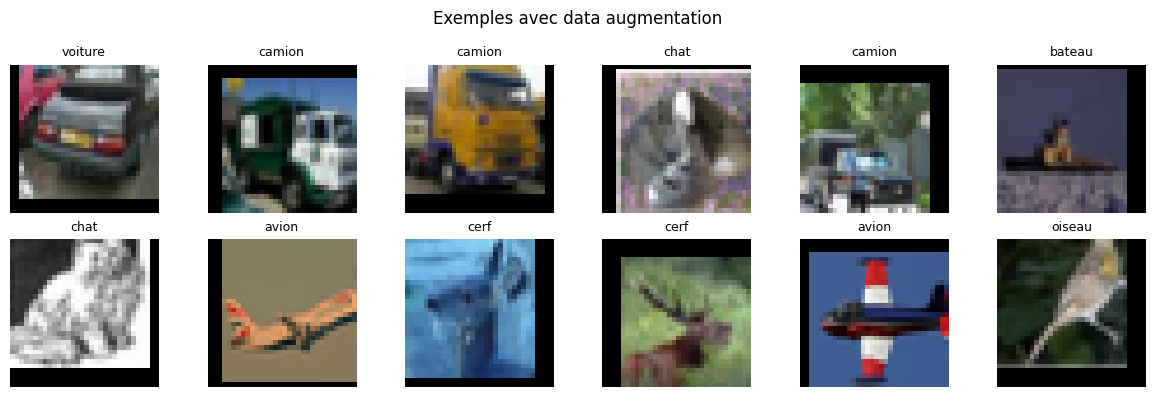

In [3]:
def unnormalize(img):
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1)

x_batch, y_batch = next(iter(make_train_loader(use_augmentation=True)))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for ax, img, label in zip(axes.ravel(), x_batch, y_batch):
    ax.imshow(unnormalize(img).permute(1, 2, 0))
    ax.set_title(CLASSES[label.item()], fontsize=9)
    ax.axis("off")
plt.suptitle("Exemples avec data augmentation")
plt.tight_layout()
plt.show()


## Partie 1 — à vous de jouer

Codez ci-dessous les différentes variantes que vous comptez tester et comparez leurs performances sur les données chargées plus haut.
